# Exploratory data analysis

A quick dive into the two datasets used in the comparison verifying the following:
1. the cross dataset labels have the correct mapping
2. correct dataset sizes, resolution and class balances
3. the domain shift and possibly identify difficulties

In this project one sample refers to one UAV RGB image and its pixel level segmentation mask

### Setup

In [34]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from src.datasets import(
COMMON_CLASS_NAMES, SemanticDroneDataset, UAVidDataset, CommonClass
)

In [35]:
# simple colour palette for vis!
COMMON_PALETTE = {
    0: (180, 30, 30),
    1: (128, 64, 128),
    2:(40, 150, 40),
    3:(220, 180, 20),
    4: (255, 22, 96),
    5: (80,80,80)
}

### loading the datasets

In [36]:
# paths for reproducibility

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SEMANTIC_DRONE_ROOT = PROJECT_ROOT / "data" / "semantic_drone"
UAVID_ROOT = PROJECT_ROOT / "data" / "uavid"

In [37]:
semantic_drone = SemanticDroneDataset(SEMANTIC_DRONE_ROOT)
uavid_train = UAVidDataset(UAVID_ROOT, split="train")
uavid_val = UAVidDataset(UAVID_ROOT, split="val")
# test is not necessary as it does not carry any masks!

In [38]:
print("Datasets lengths:\n"
      f"semantic drone = {len(semantic_drone)}\n"
      f"uavid train = {len(uavid_train)}\n"
      f"uavid val = {len(uavid_val)}")

Datasets lengths:
semantic drone = 400
uavid train = 600
uavid val = 70


In [39]:
semantic_img, semantic_mask = semantic_drone[0]
uavid_img, uavid_mask = uavid_train[0]

print(f"Semantic img shape (C, H, W): {semantic_img.shape}, semantic mask shape: {semantic_mask.shape}"
      f"\nuavid img shape{uavid_img.shape}, uavid mask shape{uavid_mask.shape}")


Semantic img shape (C, H, W): torch.Size([3, 4000, 6000]), semantic mask shape: torch.Size([4000, 6000])
uavid img shapetorch.Size([3, 2160, 3840]), uavid mask shapetorch.Size([2160, 3840])


In [40]:
print(f"semantic img type {semantic_img.dtype}, semantic mask type {semantic_mask.dtype}")
print(f"uavid img type {uavid_img.dtype}, uavid mask type {uavid_mask.dtype}")

semantic img type torch.float32, semantic mask type torch.int64
uavid img type torch.float32, uavid mask type torch.int64


In [41]:
print(semantic_img.min(), semantic_img.max())
print(uavid_img.min(), uavid_img.max())

tensor(0.) tensor(1.)
tensor(0.) tensor(1.)


In [42]:
# this is managed later anyways!
print(torch.unique(semantic_mask))
print(torch.unique(uavid_mask))

tensor([0, 1, 2, 4, 5])
tensor([0, 1, 2, 3, 4, 5])


In [43]:
def colorize_common_mask(mask: torch.Tensor)-> np.ndarray:
    """ converts HxW common class mask to HxWx3 RGB array"""
    # for passing into matplot later
    integer_mask = mask.detach().cpu().numpy()

    height, width = integer_mask.shape
    rgb_mask = np.zeros((height, width,3), np.uint8)

    for class_id, colour in COMMON_PALETTE.items():
        rgb_mask[integer_mask == class_id] = colour

    return rgb_mask

def class_pixel_counts( mask: torch.Tensor, num_classes: int = len(COMMON_CLASS_NAMES)) -> torch.Tensor:

    # for easier iteration later on the CPU!
    flat_mask = mask.detach().to(device="cpu", dtype=torch.int64).flatten()

    if flat_mask.numel() == 0:
        return torch.zeros(num_classes, dtype=torch.int64)

    return torch.bincount(flat_mask, minlength=num_classes)

In [44]:
colourized_mask = colorize_common_mask(semantic_mask)
counts = class_pixel_counts(semantic_mask)

print("colourized mask shape", colourized_mask.shape)
print("counts", counts)

print("total counted", counts.sum().item())
print("total pixels", semantic_mask.numel())


assert colourized_mask.shape == (*semantic_mask.shape, 3)
assert colourized_mask.dtype == np.uint8
assert counts.shape == (len(COMMON_CLASS_NAMES),)
assert counts.sum().item() == semantic_mask.numel()
assert semantic_mask.min().item() >= 0
assert semantic_mask.max().item() < len(COMMON_CLASS_NAMES)


colourized mask shape (4000, 6000, 3)
counts tensor([  287613, 20883680,   800941,        0,   524123,  1503643])
total counted 24000000
total pixels 24000000


In [45]:
for class_name, count in zip(COMMON_CLASS_NAMES, counts):
    percentage = 100 * count.item() / semantic_mask.numel()
    print(f"{class_name:>10}: {count.item():>10,} pixels ({percentage:6.2f}%)")

  Building:    287,613 pixels (  1.20%)
      Road: 20,883,680 pixels ( 87.02%)
Vegetation:    800,941 pixels (  3.34%)
   Vehicle:          0 pixels (  0.00%)
     Human:    524,123 pixels (  2.18%)
     Other:  1,503,643 pixels (  6.27%)


### Visual inspection of label mapping

In [46]:
sample_index = 0
image, common_mask = semantic_drone[sample_index]
image_path, original_mask_path = semantic_drone.samples[sample_index]

In [47]:
with Image.open(original_mask_path) as mask_image:
    original_mask = np.asarray(mask_image.convert("RGB"))

type(original_mask)

numpy.ndarray

In [48]:
display_stride = 4

display_img = (
    image[:,::display_stride,::display_stride].permute(1,2,0).cpu().numpy()
) # permut is bc of the super annyoning non standard order of the shape

display_original_mask = original_mask[
    ::display_stride, ::display_stride
]

display_common_mask = colorize_common_mask(common_mask[::display_stride, ::display_stride]) # downsampling

print("Displayed image:", display_img.shape)
print("Displayed original mask:", display_original_mask.shape)
print("Displayed common mask:", display_common_mask.shape)

assert display_img.shape == display_original_mask.shape
assert display_img.shape == display_common_mask.shape

Displayed image: (1000, 1500, 3)
Displayed original mask: (1000, 1500, 3)
Displayed common mask: (1000, 1500, 3)


In [49]:
from matplotlib.patches import Patch

def show_mapping(
    dataset,index: int,dataset_name: str,display_stride: int = 4,) -> None:

    # Retrieve the paths first so unlabeled samples fail clearly.
    image_path, original_mask_path = dataset.samples[index]

    if original_mask_path is None:
        raise ValueError(f"{dataset_name} sample {index} has no mask")

    image, common_mask = dataset[index]

    # Load the original dataset-specific RGB mask.
    with Image.open(original_mask_path) as mask_image:
        original_mask = np.array(mask_image.convert("RGB"), dtype=np.uint8,copy=True)


    # Downsample for display.
    display_image = (
        image[:, ::display_stride, ::display_stride]
        .permute(1, 2, 0)  # Convert PyTorch CHW to Matplotlib HWC.
        .detach()
        .cpu()
        .numpy()
    )

    display_original_mask = original_mask[
        ::display_stride,
        ::display_stride,
    ]

    display_common_mask = colorize_common_mask(
        common_mask[::display_stride, ::display_stride]
    )

    # Create the three-panel comparison.
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    panels = (
        (display_image, "RGB image"),
        (
            display_original_mask,
            f"Original {dataset_name} mask",
        ),
        (
            display_common_mask,
            "Remapped common mask",
        ),
    )

    for axis, (panel, title) in zip(axes, panels):
        axis.imshow(panel)
        axis.set_title(title)
        axis.axis("off")

    # Add a shared legend for the common-class mask.
    legend_handles = [
        Patch(
            facecolor=np.asarray(COMMON_PALETTE[class_id]) / 255,
            label=class_name,
        )
        for class_id, class_name in enumerate(COMMON_CLASS_NAMES)
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(COMMON_CLASS_NAMES),
        frameon=False,
    )

    fig.suptitle(
        f"{dataset_name} sample {index} — {image_path.name}",
        fontsize=16,
    )

    # Reserve space at the top and bottom for the title and legend.
    fig.tight_layout(rect=(0, 0.10, 1, 0.93))
    plt.show()

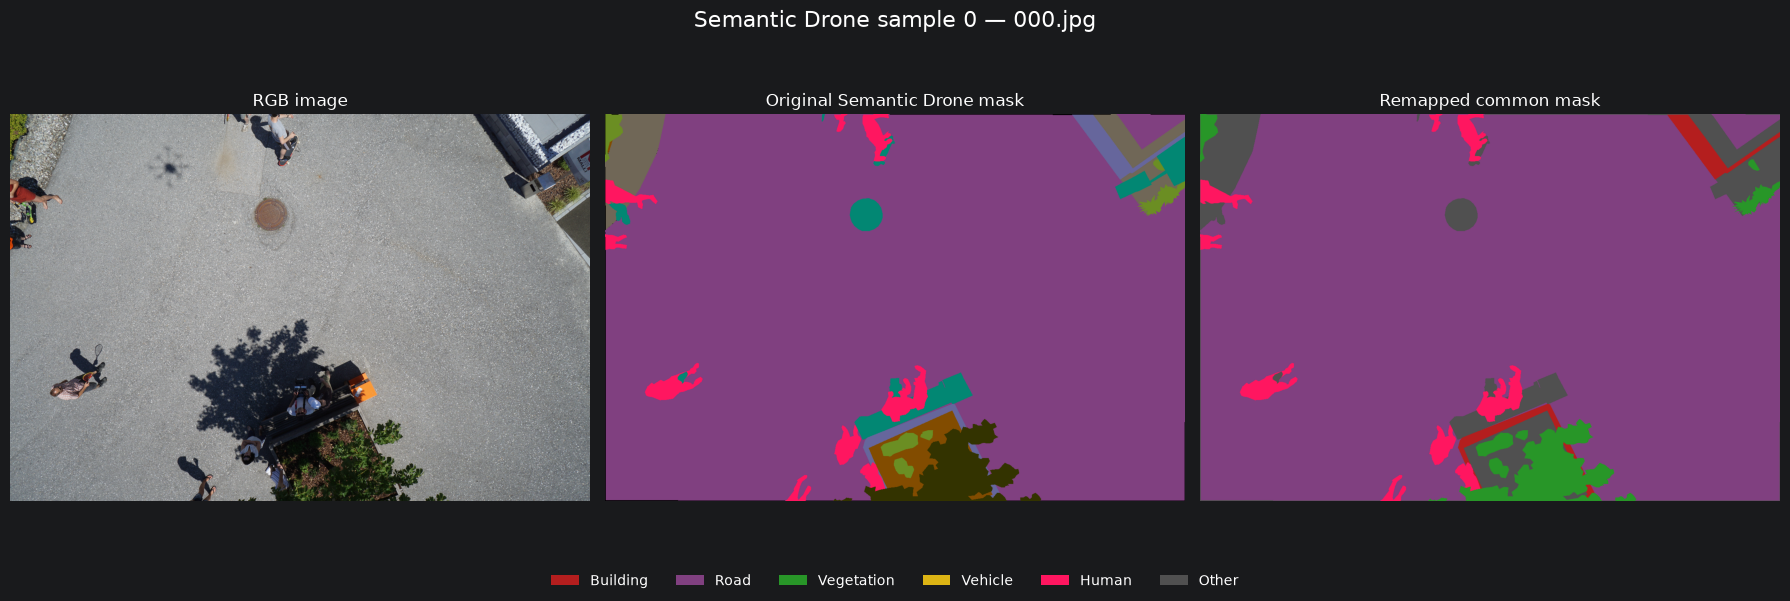

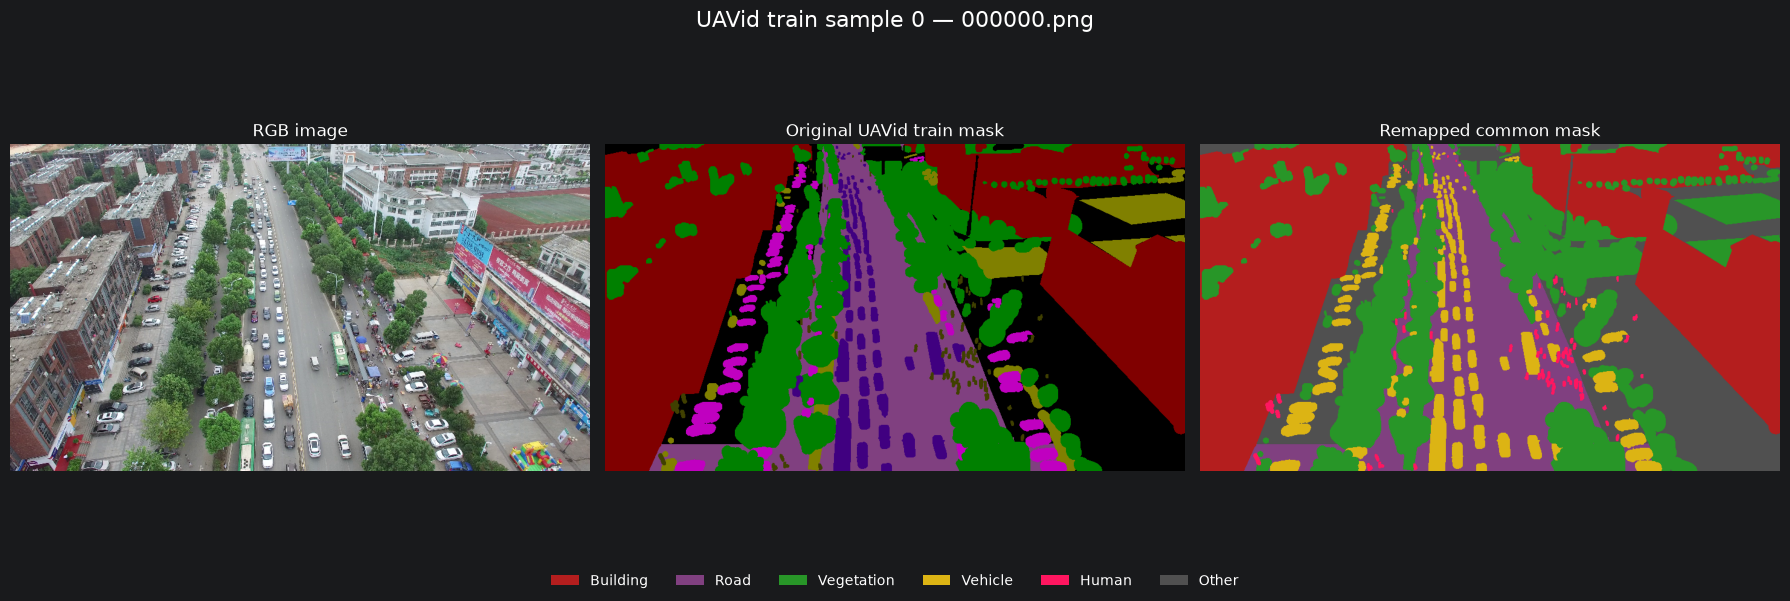

In [50]:
show_mapping(
    semantic_drone,
    index=0,
    dataset_name="Semantic Drone",
)

show_mapping(
    uavid_train,
    index=0,
    dataset_name="UAVid train",
)

## Initial observations

There seems to be a clear semantic overlap betweent the two datasets, the sample images are from different perspectives which could lead to transfer issues. Based on this sample alone (which may or may not be reprasentative) the density of semantics is considerably higher in the UAVid data. This also may create issues as we are trying to learn from rougher to more finer data.
This stands out to be analysed after training

In [56]:
from collections import Counter

def dataset_class_statistics(dataset) -> tuple[Counter[Any], Counter[Any], Counter[Any]]:

    pixel_counter = Counter()
    image_all_class_counter = Counter()
    unknown_colour_counts = Counter()

    for image_path, mask_path in dataset.samples:

        if mask_path is None:
            raise ValueError(f"The image path {image_path} has no mask")

        with Image.open(mask_path) as mask_image:
            rgb_mask = mask_image.convert("RGB")

            colour_counts = rgb_mask.getcolors(maxcolors=256)

            if colour_counts is None:
                raise ValueError(f"The mask path {mask_path} has no colours, somehting weird is wrong")

            classes_present = set()

            for pixel_count, colour in colour_counts:
                if colour in dataset.colour_mapping:
                    common_class = dataset.colour_mapping[colour]
                else:
                    unknown_colour_counts[colour] += pixel_count
                    common_class = CommonClass.OTHER

                pixel_counter[common_class] += pixel_count
                classes_present.add(common_class)

            image_all_class_counter.update(classes_present)


    return pixel_counter, image_all_class_counter, unknown_colour_counts


In [57]:
semantic_statistics = dataset_class_statistics(semantic_drone)
uavid_statistics = dataset_class_statistics(uavid_train)

In [64]:
(
    semantic_pixel_counter,
    semantic_image_counter,
    semantic_unknown_colours,
) = semantic_statistics

(
    uavid_pixel_counter,
    uavid_image_counter,
    uavid_unknown_colours,
) = uavid_statistics

def counter_to_class_array(counter):
    return np.array(
        [
            counter.get(CommonClass(class_id), 0)
            for class_id in range(len(COMMON_CLASS_NAMES))
        ],
        dtype=np.int64,
    )
semantic_pixel_counts = counter_to_class_array(
    semantic_pixel_counter
)
semantic_image_counts = counter_to_class_array(
    semantic_image_counter
)

uavid_pixel_counts = counter_to_class_array(
    uavid_pixel_counter
)
uavid_image_counts = counter_to_class_array(
    uavid_image_counter
)

semantic_pixel_share = (
    100 * semantic_pixel_counts / semantic_pixel_counts.sum()
)
uavid_pixel_share = (
    100 * uavid_pixel_counts / uavid_pixel_counts.sum()
)

semantic_image_prevalence = (
    100 * semantic_image_counts / len(semantic_drone)
)
uavid_image_prevalence = (
    100 * uavid_image_counts / len(uavid_train)
)

In [65]:
print(
    f"{'Class':<12}"
    f"{'SD pixels':>12}"
    f"{'UAVid pixels':>14}"
    f"{'SD images':>12}"
    f"{'UAVid images':>14}"
)

for class_id, class_name in enumerate(COMMON_CLASS_NAMES):
    print(
        f"{class_name:<12}"
        f"{semantic_pixel_share[class_id]:>11.2f}%"
        f"{uavid_pixel_share[class_id]:>13.2f}%"
        f"{semantic_image_prevalence[class_id]:>11.2f}%"
        f"{uavid_image_prevalence[class_id]:>13.2f}%"
    )

Class          SD pixels  UAVid pixels   SD images  UAVid images
Building          10.05%        28.14%      75.00%        99.00%
Road              37.74%        12.86%      95.00%        99.33%
Vegetation        29.14%        39.08%      98.50%       100.00%
Vehicle            0.79%         2.12%      16.00%        96.50%
Human              1.05%         0.11%      91.75%        87.67%
Other             21.23%        17.70%     100.00%       100.00%


## Observations

We have some important differences that may cause issues later on:

- The semantic drone pixels are occupied to 37.74% by the road class, UAVid in comparison only has 12.86%
- Buildings rise from ~10% to ~28 in SD to UAVid
- Vegetation is 10% more dominant relatively in UAVid
- There are stark differences in how of vehicles appear in SD images in comparison to UAVid, even though the total pixel percentage differs relatively lightly
- Humans appear similarly often in SD as in UAVid images, but occupy around 10 times less pixels in percent in UAVid in comparison to SD